# Strategy robustness — Stage 8.7

A single backtest cannot establish robustness. This notebook asks three separate
research questions: does behavior change **out of sample**, how sensitive are
results to **nearby EMA parameters**, and how does one fixed configuration behave
across **multiple later windows**?

Good historical performance alone is insufficient. Poor performance does not
become attractive merely because it is stable: **robustness and profitability are
different concepts**. The figures describe this historical sample; they do not
select parameters or produce a robust/not-robust verdict.

All trading calculations come from the accepted Stage 8.2–8.6 production APIs,
under [Decision 012](../decisions/012_strategy_robustness.md). Notebook-local
helpers only draw figures. No real money, exchange connection, or data download
is used.

## 1. Research assumptions and boundaries

We use the already-seen local BTCUSDT hourly snapshot, in chronological order.
The fixed **EMA20/50 baseline** is a reference configuration, not an optimal or
recommended strategy. Every IS/OOS/train/test segment starts independently FLAT,
with its own 10,000 USDT and fresh indicators, execution, ledger, and accounting.

The first 50 candles in **every segment** are warm-up: they remain in the
observation clock, with HOLD signals and cash. We do not seed indicators from an
earlier window, invent a boundary entry, borrow a later segment's OPEN for a fill,
or force a terminal close. Final OPEN positions retain the existing candle-CLOSE
marks. Final equity therefore differs from realized-only capital.

Fees of 0.10% per side and adverse slippage of 0.05% per side are **frozen research
assumptions**, not claims about current Bybit pricing. Allocation stays fixed at
100%. Parameter sensitivity is not optimization; walk-forward uses the same
EMA20/50 settings in each window, without parameter selection or capital carry.

## 2. Project imports

Select the project's existing `.venv` Python kernel. This setup finds the project
from either its root or `notebooks/`, then makes `src/` importable. It installs
nothing. We call public production functions rather than copying financial or
robustness calculations into research cells.

In [1]:
from pathlib import Path
import hashlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator, PercentFormatter
from IPython.display import Markdown, display

root_candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "Trading Lab"]
PROJECT_ROOT = next(
    (folder for folder in root_candidates if (folder / "src" / "trading_lab").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot find the Trading Lab project root and src/trading_lab.")
source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

from trading_lab.data.market_data import load_ohlcv_csv
from trading_lab.strategies.ema_trend import generate_ema_signals
from trading_lab.robustness import (
    evaluate_train_test_split,
    evaluate_parameter_sensitivity,
    analyze_parameter_stability,
    evaluate_expanding_walk_forward,
    summarize_train_test_diagnostics,
    summarize_walk_forward_diagnostics,
)

%matplotlib inline
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "figure.dpi": 110})
print("Project source imports ready; existing Python kernel:", sys.version.split()[0])

Project source imports ready; existing Python kernel: 3.9.6


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 3. Load and verify the frozen local data

Check SHA256 **before loading**. A missing or different file stops execution;
there is no replacement download. The production CSV loader validates the
one-hour OHLCV snapshot and its half-open research period. We retain a deep copy
so the final audit can confirm that the analysis preserved the input.

In [2]:
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"
FROZEN_SHA256 = "0be33013ae5decc74112c4a1cfdcb94b387830a37b9d1109b7f6c582d60f1975"
START = pd.Timestamp("2025-10-01 00:00", tz="UTC")
END = pd.Timestamp("2026-10-01 00:00", tz="UTC")
CANDLE_INTERVAL = pd.Timedelta(hours=1)

if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "Frozen local data/raw/BTCUSDT_1h.csv is missing; stop without downloading data."
    )
raw_hash_before = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
assert raw_hash_before == FROZEN_SHA256, "Frozen BTC snapshot SHA256 differs; stop."
candles = load_ohlcv_csv(RAW_PATH, interval="60", start=START, end=END)
candles_before = candles.copy(deep=True)
assert len(candles) == 8760
assert candles["timestamp"].iloc[0] == START
assert candles["timestamp"].iloc[-1] + CANDLE_INTERVAL == END
print("Frozen SHA256 verified:", raw_hash_before)
display(candles.head(3))

Frozen SHA256 verified: 0be33013ae5decc74112c4a1cfdcb94b387830a37b9d1109b7f6c582d60f1975


,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905


## 4. Fixed baseline and common settings

These settings are shared across research calls. The 70/30 split and walk-forward
window lengths are predefined research choices. Annualization uses 8,760 hourly
periods, with zero per-period risk-free return and minimum acceptable return
(MAR). Production analytics retain their existing conventions, including
undefined NaN/infinite values.

In [3]:
BASELINE = {"fast_span": 20, "slow_span": 50, "warmup_candles": 50}
INITIAL_CAPITAL = 10_000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
POSITION_FRACTION = 1.0
TRAIN_FRACTION = 0.70
INITIAL_TRAIN_ROWS = 4380
TEST_ROWS = 1460
PARAMETER_GRID = {
    "fast_span": [10, 15, 20, 25, 30],
    "slow_span": [40, 50, 60, 70, 80],
}
FINANCIAL_SETTINGS = {
    "candle_interval": CANDLE_INTERVAL,
    "initial_capital": INITIAL_CAPITAL,
    "fee_rate": FEE_RATE,
    "slippage_rate": SLIPPAGE_RATE,
    "position_fraction": POSITION_FRACTION,
}
ANALYTICS_SETTINGS = {
    "periods_per_year": 8760.0,
    "risk_free_return_per_period": 0.0,
    "minimum_acceptable_return_per_period": 0.0,
}

configuration = pd.DataFrame([
    ("Dataset rows", len(candles)),
    ("Start timestamp", candles["timestamp"].iloc[0]),
    ("End-exclusive boundary", candles["timestamp"].iloc[-1] + CANDLE_INTERVAL),
    ("Candle interval", CANDLE_INTERVAL),
    ("Baseline EMA fast / slow", f"{BASELINE['fast_span']} / {BASELINE['slow_span']}"),
    ("Warm-up candles in every segment", BASELINE["warmup_candles"]),
    ("Initial capital per independent segment (USDT)", INITIAL_CAPITAL),
    ("Fee rate per side (research assumption)", FEE_RATE),
    ("Adverse slippage per side (research assumption)", SLIPPAGE_RATE),
    ("Position fraction", POSITION_FRACTION),
    ("Chronological train fraction", TRAIN_FRACTION),
    ("Walk-forward initial train rows", INITIAL_TRAIN_ROWS),
    ("Walk-forward test rows", TEST_ROWS),
    ("Periods per year", ANALYTICS_SETTINGS["periods_per_year"]),
    ("Per-period risk-free return / MAR", "0.0 / 0.0"),
], columns=["Setting", "Value"])
display(configuration.set_index("Setting"))

,Value
Setting,
Dataset rows,8760
Start timestamp,2025-10-01 00:00:00+00:00
End-exclusive boundary,2026-10-01 00:00:00+00:00
Candle interval,0 days 01:00:00
Baseline EMA fast / slow,20 / 50
Warm-up candles in every segment,50
Initial capital per independent segment (USDT),10000.0
Fee rate per side (research assumption),0.001
Adverse slippage per side (research assumption),0.0005


## 5. Chronological in-sample / out-of-sample evaluation

IS uses the earlier candles; OOS uses the later candles. Keeping time order
prevents a future observation from informing an earlier signal. The OOS run
starts independently, so it does not inherit IS indicators or positions.
This checks behavior across time inside an already-inspected sample; it is not
pristine unseen validation.

The evaluator supplies the financial frames; the diagnostics API supplies the
metrics and neutral OOS-minus-IS comparisons. Tables below select relevant
columns without modifying the production outputs. Drawdown is a signed decline;
more negative values mean a deeper observed loss from a prior peak.

The comparison table retains raw production units: equity is USDT, return/
drawdown/exposure are decimal ratios (0.01 = one percentage point), and
Sharpe/Sortino are ratios. Its differences are descriptive, not grades.

In [4]:
train_test_result = evaluate_train_test_split(
    candles, generate_ema_signals,
    train_fraction=TRAIN_FRACTION,
    strategy_kwargs=BASELINE,
    **FINANCIAL_SETTINGS,
)
train_test_diagnostics = summarize_train_test_diagnostics(
    train_test_result, **ANALYTICS_SETTINGS,
)
segment_metrics = train_test_diagnostics["segment_metrics"]
assert train_test_result["split_index"] == 6132
assert len(train_test_result["in_sample"]["strategy_output"]) == 6132
assert len(train_test_result["out_of_sample"]["strategy_output"]) == 2628
assert train_test_result["split_timestamp"] == pd.Timestamp("2026-06-13 12:00", tz="UTC")
assert segment_metrics["initial_equity"].eq(INITIAL_CAPITAL).all()
print("Chronological split:", train_test_result["split_index"], "/", len(candles) - train_test_result["split_index"])
print("First OOS candle:", train_test_result["split_timestamp"])

display(segment_metrics[[
    "segment", "trade_count", "exposure_ratio", "net_final_equity",
    "net_total_return", "net_max_portfolio_drawdown", "net_sharpe", "net_sortino",
]].style.format({
    "exposure_ratio": "{:.2%}", "net_final_equity": "{:,.2f}",
    "net_total_return": "{:.2%}", "net_max_portfolio_drawdown": "{:.2%}",
    "net_sharpe": "{:.3f}", "net_sortino": "{:.3f}",
}))
display(train_test_diagnostics["comparison"].style.format({
    "in_sample_value": "{:,.4f}", "out_of_sample_value": "{:,.4f}",
    "oos_minus_is": "{:,.4f}",
}))

Chronological split: 6132 / 2628
First OOS candle: 2026-06-13 12:00:00+00:00


,segment,trade_count,exposure_ratio,net_final_equity,net_total_return,net_max_portfolio_drawdown,net_sharpe,net_sortino
0,IN_SAMPLE,54,43.75%,"6,770.82",-32.29%,-34.50%,-1.884,-2.617
1,OUT_OF_SAMPLE,24,49.96%,"10,916.04",9.16%,-11.20%,1.206,1.946


,metric,in_sample_value,out_of_sample_value,oos_minus_is
0,trade_count,54.0000,24.0000,-30.0000
1,closed_trade_count,53.0000,23.0000,-30.0000
2,exposure_ratio,0.4375,0.4996,0.0621
3,gross_final_equity,"7,949.5956","11,713.3882","3,763.7926"
4,net_final_equity,"6,770.8163","10,916.0381","4,145.2218"
5,gross_total_return,-0.2050,0.1713,0.3764
6,net_total_return,-0.3229,0.0916,0.4145
7,gross_max_portfolio_drawdown,-0.2768,-0.0831,0.1937
8,net_max_portfolio_drawdown,-0.3450,-0.1120,0.2330
9,gross_sharpe,-1.0531,2.0730,3.1261


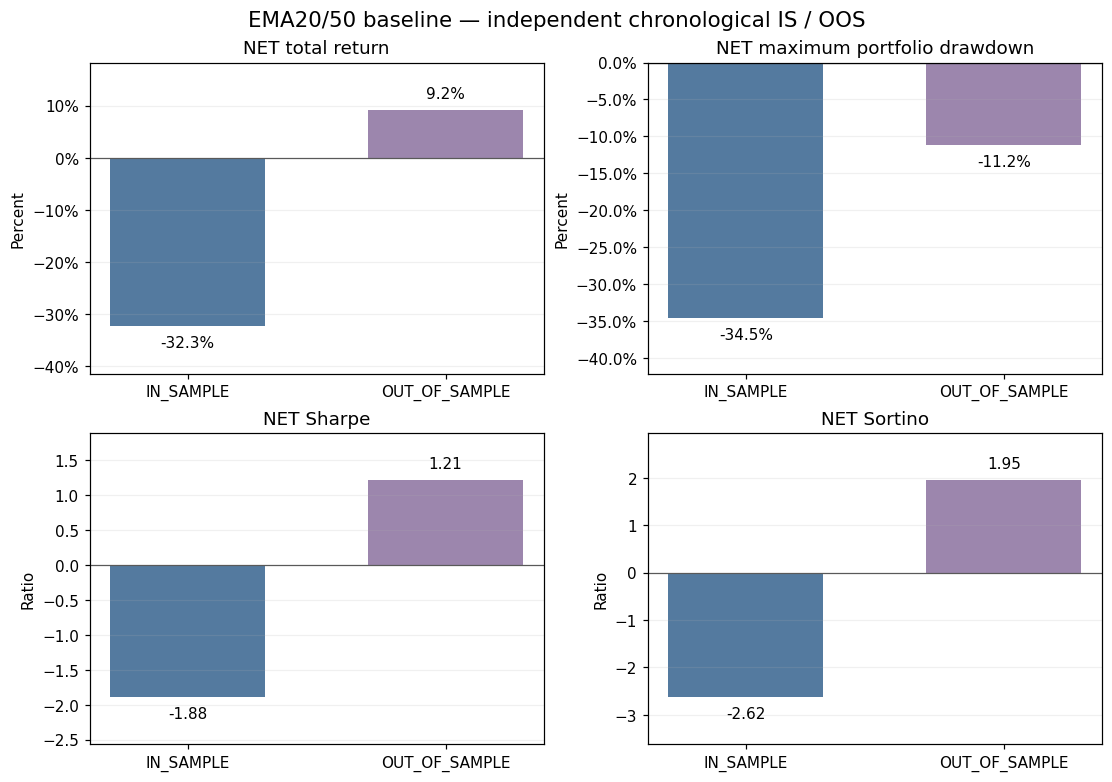

In [5]:
# This helper formats values for plots only; non-finite values remain explicit.
def plot_value(value, unit):
    if np.isnan(value):
        return "NaN"
    if np.isposinf(value):
        return "+∞"
    if np.isneginf(value):
        return "−∞"
    if unit == "percent":
        return f"{value:.1%}"
    if unit == "USDT":
        return f"{value:,.0f}"
    return f"{value:.2f}"


def metric_bars(ax, labels, values, title, unit, colors):
    """Draw supplied diagnostics; never calculate a metric or replace NaN with zero."""
    values = np.asarray(values, dtype=float)
    positions = np.arange(len(values))
    finite = np.isfinite(values)
    ax.bar(positions[finite], values[finite], color=np.asarray(colors)[finite], width=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Percent" if unit == "percent" else "Ratio")
    if unit == "percent":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.margins(y=0.22)
    ax.grid(axis="y", alpha=0.18)
    for position, value in zip(positions, values):
        above = not np.isfinite(value) or value >= 0
        ax.annotate(
            plot_value(value, unit),
            (position, value if np.isfinite(value) else 0),
            xytext=(0, 6 if above else -6), textcoords="offset points",
            ha="center", va="bottom" if above else "top", fontsize=10,
        )


fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
panels = [
    ("net_total_return", "NET total return", "percent"),
    ("net_max_portfolio_drawdown", "NET maximum portfolio drawdown", "percent"),
    ("net_sharpe", "NET Sharpe", "ratio"),
    ("net_sortino", "NET Sortino", "ratio"),
]
for ax, (metric, title, unit) in zip(axes.flat, panels):
    metric_bars(ax, ["IN_SAMPLE", "OUT_OF_SAMPLE"], segment_metrics[metric],
                title, unit, ["#547a9f", "#9c86ad"])
fig.suptitle("EMA20/50 baseline — independent chronological IS / OOS", fontsize=14)
plt.show()

## 6. Parameter sensitivity — a predefined surface

The accepted 5 × 5 grid changes fast and slow EMA spans while keeping warm-up,
data split, costs, allocation, and analytics settings fixed. Each combination
gets its own cold-start IS and OOS run. We compute the grid **once**, then reuse
its table for every parameter figure.

Rows retain the supplied Cartesian order: fast spans 10, 15, 20, 25, 30; slow
spans 40, 50, 60, 70, 80. We do not rank or select a pair. A broad area of similar
outcomes is different evidence from an isolated favorable cell; neither alone
establishes future profitability.

In [6]:
sensitivity_result = evaluate_parameter_sensitivity(
    candles, generate_ema_signals, PARAMETER_GRID,
    train_fraction=TRAIN_FRACTION,
    strategy_kwargs={"warmup_candles": BASELINE["warmup_candles"]},
    **FINANCIAL_SETTINGS, **ANALYTICS_SETTINGS,
)
sensitivity_table = sensitivity_result["results"]
assert len(sensitivity_table) == 25
assert sensitivity_result["parameter_names"] == ("fast_span", "slow_span")
assert sensitivity_result["split_index"] == train_test_result["split_index"]
assert sensitivity_result["split_timestamp"] == train_test_result["split_timestamp"]
baseline_mask = sensitivity_table["fast_span"].eq(20) & sensitivity_table["slow_span"].eq(50)
assert baseline_mask.sum() == 1
display(sensitivity_table[[
    "fast_span", "slow_span", "oos_net_final_equity",
    "oos_net_max_portfolio_drawdown", "oos_net_sharpe", "oos_net_sortino",
]].style.format({
    "oos_net_final_equity": "{:,.2f}", "oos_net_max_portfolio_drawdown": "{:.2%}",
    "oos_net_sharpe": "{:.3f}", "oos_net_sortino": "{:.3f}",
}))

,fast_span,slow_span,oos_net_final_equity,oos_net_max_portfolio_drawdown,oos_net_sharpe,oos_net_sortino
0,10,40,"9,904.72",-13.65%,0.018,0.029
1,10,50,"10,534.52",-11.88%,0.766,1.222
2,10,60,"10,779.53",-12.50%,1.053,1.690
3,10,70,"10,684.26",-12.11%,0.946,1.514
4,10,80,"10,655.44",-11.85%,0.913,1.461
5,15,40,"10,882.40",-12.32%,1.167,1.895
6,15,50,"10,966.30",-12.49%,1.261,2.040
7,15,60,"10,713.31",-12.73%,0.978,1.572
8,15,70,"11,523.82",-10.10%,1.852,3.037
9,15,80,"11,448.41",-11.85%,1.782,2.926


### Reading the parameter maps

X is `slow_span`; Y is `fast_span`, in the supplied level order. Each annotation
is an existing production value. An outline marks **Baseline 20/50**, without
marking a winner. Color encodes numeric magnitude separately for each panel;
the colorbars show its units, not a quality classification.

The plotting helper pivots a supplied table only. If a value is NaN or ±infinity,
it is masked **for color mapping only** and labeled explicitly. The source value
is never replaced with zero. Equity includes final OPEN marks; Sharpe uses
hourly returns; drawdown observes candle CLOSEs rather than intrabar lows.

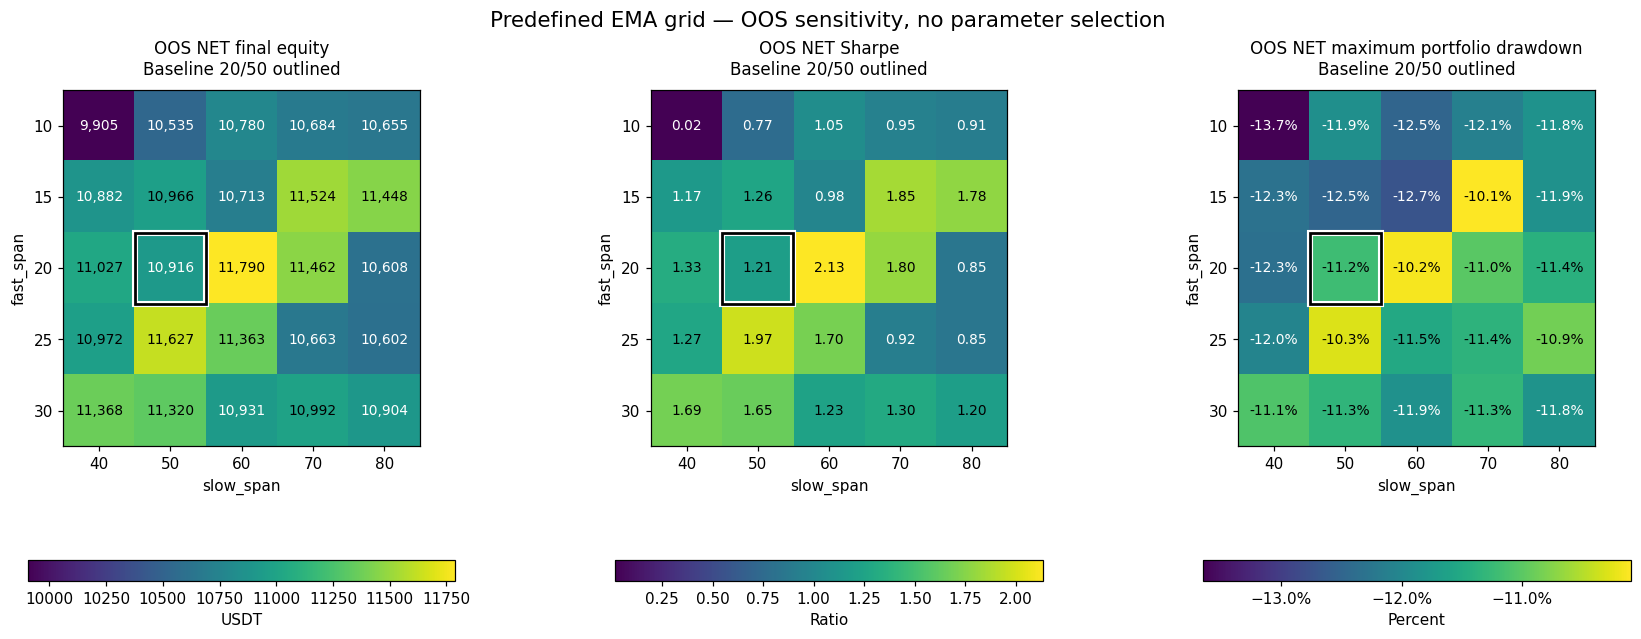

In [7]:
def parameter_heatmap(ax, table, metric, title, unit):
    """Present an existing parameter metric; no trading or neighborhood calculations."""
    fast_levels = PARAMETER_GRID["fast_span"]
    slow_levels = PARAMETER_GRID["slow_span"]
    surface = table.pivot(index="fast_span", columns="slow_span", values=metric)
    values = surface.reindex(index=fast_levels, columns=slow_levels).to_numpy(dtype=float, copy=True)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#dddddd")
    picture = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, aspect="equal")
    ax.set_xticks(np.arange(len(slow_levels)))
    ax.set_xticklabels(slow_levels)
    ax.set_yticks(np.arange(len(fast_levels)))
    ax.set_yticklabels(fast_levels)
    ax.set_xlabel("slow_span")
    ax.set_ylabel("fast_span")
    ax.set_title(f"{title}\nBaseline 20/50 outlined", fontsize=11, pad=10)
    for row in range(len(fast_levels)):
        for column in range(len(slow_levels)):
            value = values[row, column]
            text_color = "white" if np.isfinite(value) and picture.norm(value) < 0.55 else "black"
            ax.text(column, row, plot_value(value, unit), ha="center", va="center",
                    color=text_color, fontsize=9)
    baseline_x = slow_levels.index(BASELINE["slow_span"])
    baseline_y = fast_levels.index(BASELINE["fast_span"])
    for edge_color, width in [("white", 4), ("black", 1.8)]:
        ax.add_patch(Rectangle((baseline_x - 0.5, baseline_y - 0.5), 1, 1,
                               fill=False, edgecolor=edge_color, linewidth=width))
    colorbar = ax.figure.colorbar(picture, ax=ax, orientation="horizontal", pad=0.17,
                                 fraction=0.06, shrink=0.9)
    colorbar.set_label("USDT" if unit == "USDT" else "Percent" if unit == "percent" else "Ratio")
    if unit == "percent":
        colorbar.locator = MaxNLocator(nbins=4)
        colorbar.formatter = PercentFormatter(1.0, decimals=1)
        colorbar.update_ticks()


fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), constrained_layout=True)
for ax, metric, title, unit in zip(
    axes,
    ["oos_net_final_equity", "oos_net_sharpe", "oos_net_max_portfolio_drawdown"],
    ["OOS NET final equity", "OOS NET Sharpe", "OOS NET maximum portfolio drawdown"],
    ["USDT", "ratio", "percent"],
):
    parameter_heatmap(ax, sensitivity_table, metric, title, unit)
fig.suptitle("Predefined EMA grid — OOS sensitivity, no parameter selection", fontsize=14)
plt.show()

## 7. Local parameter stability

Stage 8.4 measures variation around each cell in the existing sensitivity table;
it does not rerun backtests. Adjacency follows the two supplied parameter axes,
including diagonals. The primary view uses OOS NET Sharpe, while separate
production stability objects also retain equity and drawdown variation.

Smaller `mean_absolute_delta` means nearby finite cells are numerically more
similar to the center. `local_range` spans the finite center and neighbors.
These are local descriptive statistics, **not a universal robustness score**.
A smooth surface could consist entirely of losing outcomes. Conversely, an
isolated profitable spike is fragile evidence rather than a parameter choice.

In [8]:
stability_results = {
    metric: analyze_parameter_stability(sensitivity_result, metric)
    for metric in [
        "oos_net_final_equity", "oos_net_sharpe", "oos_net_max_portfolio_drawdown",
    ]
}
sharpe_stability = stability_results["oos_net_sharpe"]["local_stability"]
display(sharpe_stability[[
    "fast_span", "slow_span", "metric_value", "neighbor_count", "neighbor_mean",
    "neighbor_std", "mean_absolute_delta", "max_absolute_delta", "local_range",
]].style.format({
    column: "{:.3f}" for column in [
        "metric_value", "neighbor_mean", "neighbor_std",
        "mean_absolute_delta", "max_absolute_delta", "local_range",
    ]
}))

,fast_span,slow_span,metric_value,neighbor_count,neighbor_mean,neighbor_std,mean_absolute_delta,max_absolute_delta,local_range
0,10,40,0.018,3,1.065,0.263,1.047,1.243,1.243
1,10,50,0.766,5,0.896,0.502,0.429,0.748,1.243
2,10,60,1.053,5,1.161,0.425,0.295,0.799,1.086
3,10,70,0.946,5,1.316,0.461,0.383,0.906,0.939
4,10,80,0.913,3,1.527,0.504,0.613,0.939,0.939
5,15,40,1.167,5,0.916,0.548,0.369,1.149,1.310
6,15,50,1.261,8,1.081,0.590,0.415,1.243,2.116
7,15,60,0.978,8,1.378,0.491,0.461,1.157,1.368
8,15,70,1.852,8,1.307,0.511,0.616,1.004,1.287
9,15,80,1.782,5,1.272,0.508,0.546,0.934,1.004


### The exact baseline neighborhood

The following is the full production stability row for EMA20/50, transposed for
readability. It has eight geometric neighbors because the baseline is an interior
cell. `finite_neighbor_count` reports how many supplied neighbor values enter
finite-only statistics; sample standard deviation uses the accepted production
convention. No neighborhood is reconstructed in this notebook.

In [9]:
baseline_stability = sharpe_stability.loc[
    sharpe_stability["fast_span"].eq(20) & sharpe_stability["slow_span"].eq(50)
]
assert len(baseline_stability) == 1
assert baseline_stability["neighbor_count"].iloc[0] == 8
display(baseline_stability.set_index(["fast_span", "slow_span"]).T)

fast_span,20
slow_span,50
metric_value,1.206086
neighbor_count,8.000000
finite_neighbor_count,8.000000
neighbor_mean,1.475823
neighbor_std,0.410717
neighbor_min,0.977862
neighbor_max,2.134476
mean_absolute_delta,0.336521
max_absolute_delta,0.928390


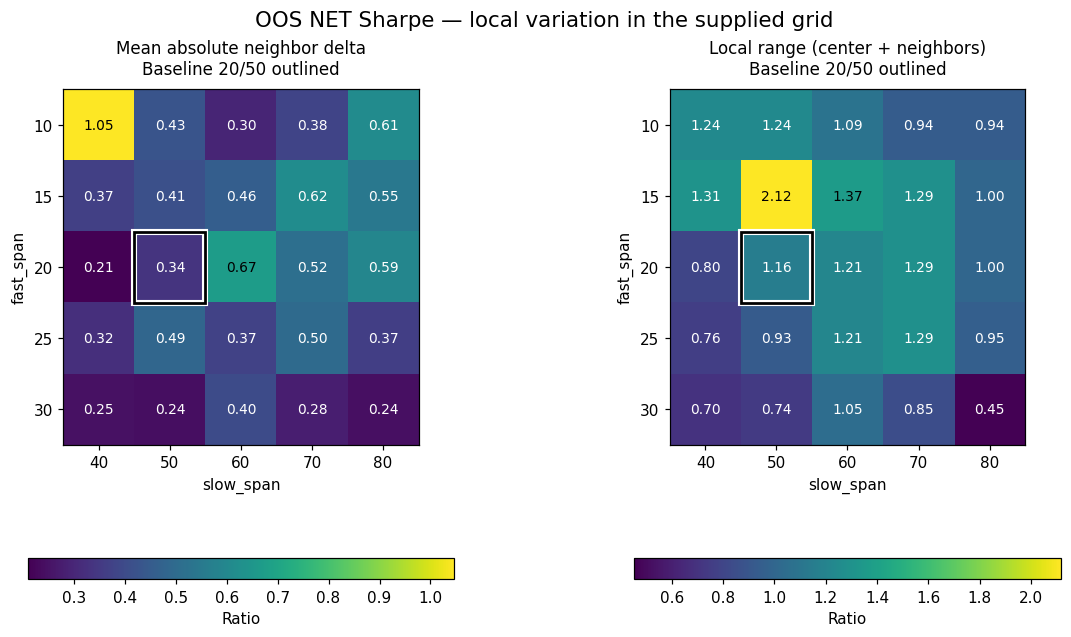

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.8), constrained_layout=True)
parameter_heatmap(axes[0], sharpe_stability, "mean_absolute_delta",
                  "Mean absolute neighbor delta", "ratio")
parameter_heatmap(axes[1], sharpe_stability, "local_range",
                  "Local range (center + neighbors)", "ratio")
fig.suptitle("OOS NET Sharpe — local variation in the supplied grid", fontsize=14)
plt.show()

## 8. Expanding fixed-configuration walk-forward

Training starts with 4,380 rows, then expands to 5,840 and 7,300. Each following
test contains 1,460 rows. These are **row-count windows**, not exact calendar
months. Three full tests use the remaining data with zero unused tail rows.

Every train and test cold-starts independently with EMA20/50, 50 warm-up candles,
and the same financial assumptions. Training is not used to select parameters.
Tests are non-overlapping, but that does not make their capital continuous.
Different train lengths also make endpoint train returns different-horizon
observations, rather than directly comparable annual rates.

In [11]:
walk_forward_result = evaluate_expanding_walk_forward(
    candles, generate_ema_signals,
    initial_train_rows=INITIAL_TRAIN_ROWS, test_rows=TEST_ROWS,
    strategy_kwargs=BASELINE, **FINANCIAL_SETTINGS,
)
walk_forward_diagnostics = summarize_walk_forward_diagnostics(
    walk_forward_result, **ANALYTICS_SETTINGS,
)
window_metrics = walk_forward_diagnostics["window_metrics"]
assert len(walk_forward_result["windows"]) == 3
assert walk_forward_result["unused_tail_rows"] == 0
assert window_metrics["train_rows"].tolist() == [4380, 5840, 7300]
assert window_metrics["test_rows"].tolist() == [1460, 1460, 1460]
assert window_metrics["train_initial_equity"].eq(INITIAL_CAPITAL).all()
assert window_metrics["test_initial_equity"].eq(INITIAL_CAPITAL).all()

display(window_metrics[[
    "window_id", "train_rows", "test_rows", "test_start_timestamp", "test_last_timestamp",
]])
display(window_metrics[[
    "window_id", "train_net_total_return", "test_net_total_return",
    "train_net_sharpe", "test_net_sharpe",
    "train_net_max_portfolio_drawdown", "test_net_max_portfolio_drawdown",
]].style.format({
    column: "{:.2%}" if "return" in column or "drawdown" in column else "{:.3f}"
    for column in window_metrics.columns
    if column in [
        "train_net_total_return", "test_net_total_return", "train_net_sharpe",
        "test_net_sharpe", "train_net_max_portfolio_drawdown", "test_net_max_portfolio_drawdown",
    ]
}))

,window_id,train_rows,test_rows,test_start_timestamp,test_last_timestamp
0,1,4380,1460,2026-04-01 12:00:00+00:00,2026-06-01 07:00:00+00:00
1,2,5840,1460,2026-06-01 08:00:00+00:00,2026-08-01 03:00:00+00:00
2,3,7300,1460,2026-08-01 04:00:00+00:00,2026-09-30 23:00:00+00:00


,window_id,train_net_total_return,test_net_total_return,train_net_sharpe,test_net_sharpe,train_net_max_portfolio_drawdown,test_net_max_portfolio_drawdown
0,1,-31.30%,1.84%,-2.577,0.541,-34.50%,-10.83%
1,2,-32.20%,-6.25%,-1.971,-1.431,-34.50%,-10.77%
2,3,-36.44%,19.65%,-1.871,3.666,-36.60%,-10.21%


### Descriptive statistics across independent tests

The diagnostics API summarizes finite test values only; `finite_count` makes the
coverage explicit. NaN/±infinity remain unchanged in raw window tables and are
not silently replaced with zero. The mean or median describes independent test
outcomes, **not a compounded portfolio return**. Three tests are limited evidence.

In [12]:
test_metric_summary = walk_forward_diagnostics["test_metric_summary"]
summary_metrics = [
    "net_final_equity", "net_total_return", "net_sharpe", "net_sortino",
    "net_max_portfolio_drawdown", "exposure_ratio",
]
display(test_metric_summary.loc[test_metric_summary["metric"].isin(summary_metrics)]
        .style.format({column: "{:,.4f}" for column in ["mean", "median", "minimum", "maximum"]}))

,metric,finite_count,mean,median,minimum,maximum
2,exposure_ratio,3,0.5260,0.5260,0.5041,0.5479
4,net_final_equity,3,"10,507.5238","10,183.5015","9,374.5487","11,964.5212"
6,net_total_return,3,0.0508,0.0184,-0.0625,0.1965
8,net_max_portfolio_drawdown,3,-0.1060,-0.1077,-0.1083,-0.1021
11,net_sharpe,3,0.9251,0.5406,-1.4308,3.6655
12,net_sortino,3,1.7089,0.8097,-2.0897,6.4065


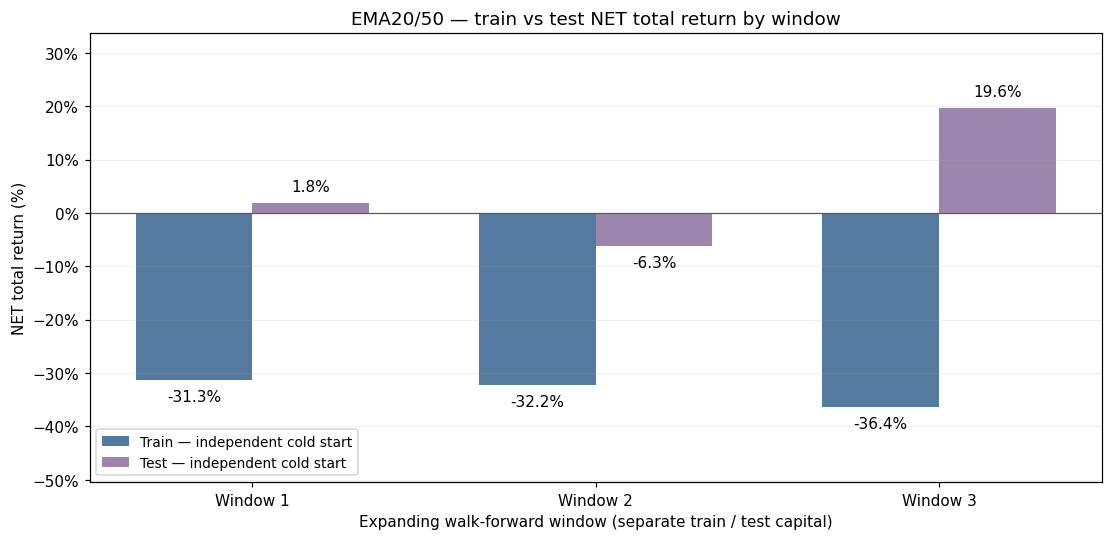

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
positions = np.arange(len(window_metrics))
width = 0.34
for offset, column, label, color in [
    (-width / 2, "train_net_total_return", "Train — independent cold start", "#547a9f"),
    (width / 2, "test_net_total_return", "Test — independent cold start", "#9c86ad"),
]:
    values = window_metrics[column].to_numpy(copy=True)
    finite = np.isfinite(values)
    ax.bar(positions[finite] + offset, values[finite], width=width, label=label, color=color)
    for position, value in zip(positions + offset, values):
        above = not np.isfinite(value) or value >= 0
        ax.annotate(plot_value(value, "percent"), (position, value if np.isfinite(value) else 0),
                    xytext=(0, 6 if above else -6), textcoords="offset points",
                    ha="center", va="bottom" if above else "top")
ax.set_xticks(positions)
ax.set_xticklabels([f"Window {number}" for number in window_metrics["window_id"]])
ax.set_title("EMA20/50 — train vs test NET total return by window")
ax.set_xlabel("Expanding walk-forward window (separate train / test capital)")
ax.set_ylabel("NET total return (%)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.axhline(0, color="0.35", linewidth=0.8)
ax.margins(y=0.25)
ax.grid(axis="y", alpha=0.18)
ax.legend(loc="lower left", fontsize=9)
plt.show()

### Independent test equity paths — a display index

For visual comparability only, divide each test's existing NET equity by **its
own first equity observation**, then multiply by 100. This is a presentation
transform, not a new financial metric. Each line starts at its own 100; the X
axis resets to observation zero for each test.

Warm-up cash observations remain visible. The paths are never concatenated,
stitched, or compounded across tests. Their final marks include OPEN positions
under the existing equity contract, without hypothetical liquidation costs.

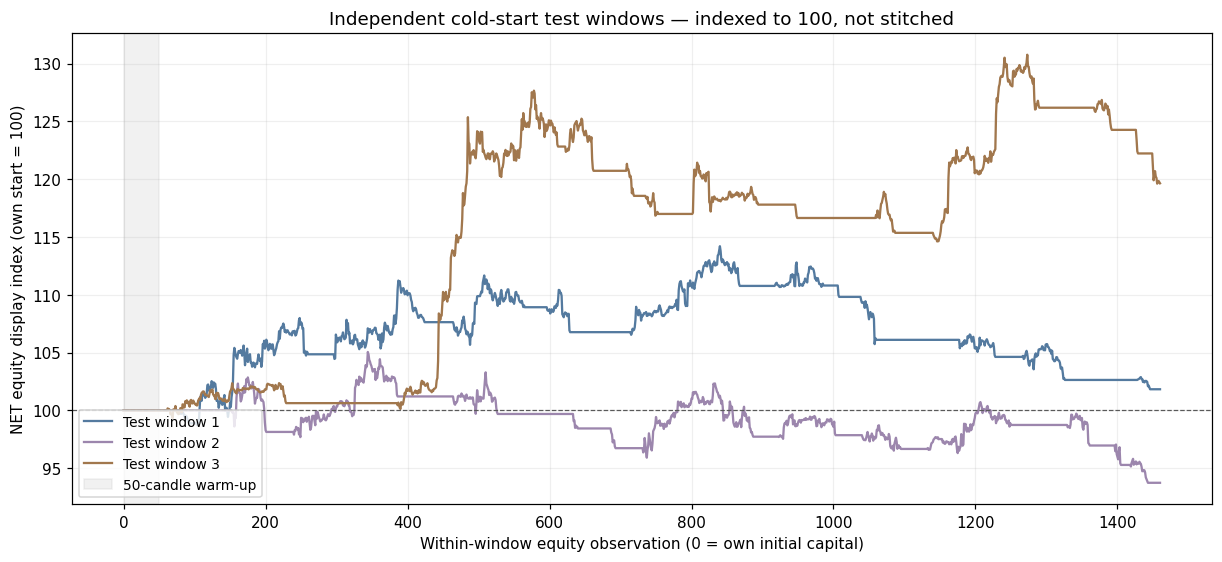

In [14]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for window, color in zip(walk_forward_result["windows"], ["#547a9f", "#9c86ad", "#a1774d"]):
    path = window["test"]["net_equity"]
    display_index = path["equity"] / path["equity"].iloc[0] * 100
    ax.plot(np.arange(len(path)), display_index,
            label=f"Test window {window['window_id']}", color=color, linewidth=1.5)
ax.axhline(100, color="0.35", linewidth=0.8, linestyle="--")
ax.axvspan(0, BASELINE["warmup_candles"], color="0.7", alpha=0.18, label="50-candle warm-up")
ax.set_title("Independent cold-start test windows — indexed to 100, not stitched", fontsize=12)
ax.set_xlabel("Within-window equity observation (0 = own initial capital)")
ax.set_ylabel("NET equity display index (own start = 100)")
ax.grid(alpha=0.2)
ax.legend(loc="lower left", fontsize=9)
plt.show()

### Test-window diagnostics side by side

One bar per independent test shows NET total return, hourly-return Sharpe, and
candle-CLOSE maximum portfolio drawdown. These are the existing diagnostics
values, not cumulative returns or compounded capital. Returns/drawdowns use
percentages; Sharpe remains a ratio. Numerical colors do not declare a verdict.

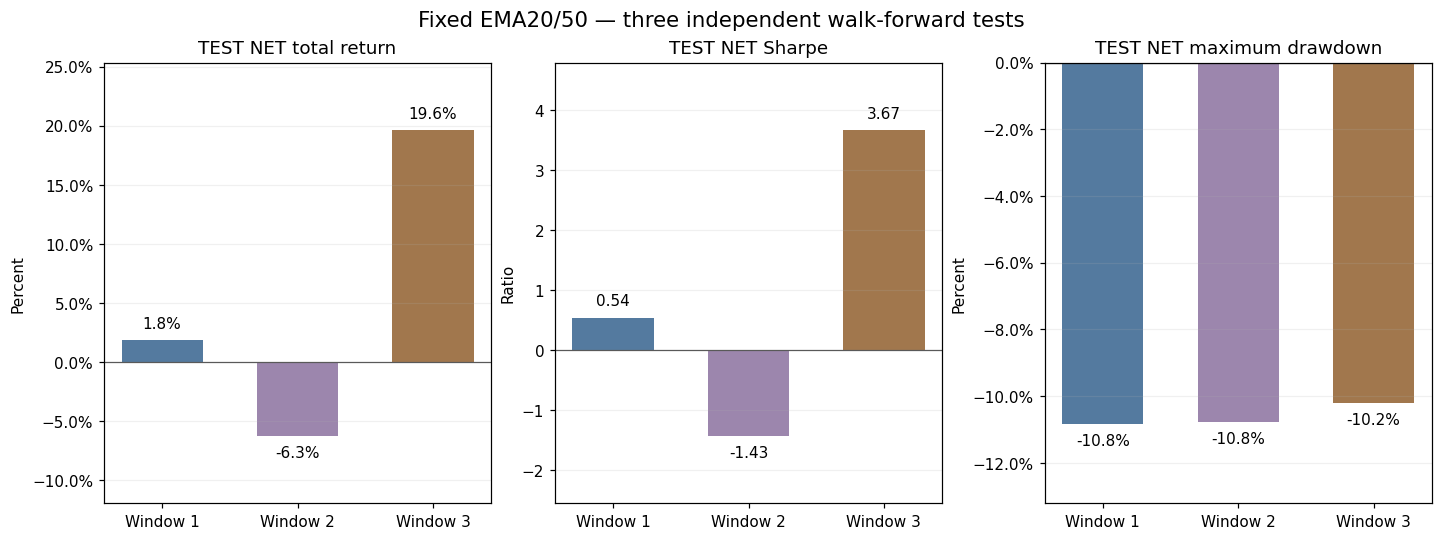

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), constrained_layout=True)
for ax, (metric, title, unit) in zip(axes, [
    ("test_net_total_return", "TEST NET total return", "percent"),
    ("test_net_sharpe", "TEST NET Sharpe", "ratio"),
    ("test_net_max_portfolio_drawdown", "TEST NET maximum drawdown", "percent"),
]):
    metric_bars(ax, [f"Window {number}" for number in window_metrics["window_id"]],
                window_metrics[metric], title, unit, ["#547a9f", "#9c86ad", "#a1774d"])
fig.suptitle("Fixed EMA20/50 — three independent walk-forward tests", fontsize=14)
plt.show()

## 9. Combined interpretation within this sample

Read the four kinds of evidence together: a time split can differ even when a
parameter neighborhood looks similar; local similarity can coexist with poor
returns; later fixed-configuration tests can differ from both training and the
single OOS segment. The following observations read already-computed outputs,
without ranking the grid or changing the baseline.

In [16]:
is_row = segment_metrics.loc[segment_metrics["segment"].eq("IN_SAMPLE")].iloc[0]
oos_row = segment_metrics.loc[segment_metrics["segment"].eq("OUT_OF_SAMPLE")].iloc[0]
reference_10_40 = sensitivity_table.loc[
    sensitivity_table["fast_span"].eq(10) & sensitivity_table["slow_span"].eq(40)
].iloc[0]
reference_30_80 = sensitivity_table.loc[
    sensitivity_table["fast_span"].eq(30) & sensitivity_table["slow_span"].eq(80)
].iloc[0]
local_row = baseline_stability.iloc[0]
test_return_summary = test_metric_summary.loc[test_metric_summary["metric"].eq("net_total_return")].iloc[0]
test_return_labels = ", ".join(
    f"window {row.window_id}: {row.test_net_total_return:.2%}"
    for row in window_metrics.itertuples(index=False)
)
display(Markdown(f"""
- **Time split:** the baseline NET total return is {is_row.net_total_return:.2%}
  in IS versus {oos_row.net_total_return:.2%} in OOS. NET Sharpe is
  {is_row.net_sharpe:.3f} versus {oos_row.net_sharpe:.3f}. The later period differs
  from the earlier period; these are separate starts and unequal time horizons.
- **Sensitivity surface:** the predefined 10/40 and 30/80 reference cells have
  OOS NET equity {reference_10_40.oos_net_final_equity:,.2f} and
  {reference_30_80.oos_net_final_equity:,.2f} USDT, with NET Sharpe
  {reference_10_40.oos_net_sharpe:.3f} and {reference_30_80.oos_net_sharpe:.3f}.
  These are fixed examples, not selected extremes. Read all 25 cells to examine
  broad areas of similar outcomes and sharp neighboring changes. The OOS maps
  show many neighboring positive outcomes alongside visible variation; this
  later-period behavior does not erase the negative baseline IS result.
- **Local surface:** baseline 20/50 has {int(local_row.neighbor_count)} geometric
  neighbors, mean absolute Sharpe delta {local_row.mean_absolute_delta:.3f},
  and local range {local_row.local_range:.3f}. The maps show where numerical
  similarity varies across the supplied grid; neither statistic is a quality
  threshold or robustness score.
- **Later windows:** independent test NET returns are {test_return_labels}.
  The production summary reports a finite-only mean of
  {test_return_summary['mean']:.2%} across {int(test_return_summary.finite_count)}
  finite tests. This describes variation in this sample, not a combined return.

No favorable cell or window validates the strategy. A smooth losing surface is
locally stable but still unattractive; an isolated profitable spike is fragile
evidence. No winner, ranking, optimizer, or trading recommendation follows.
"""))


- **Time split:** the baseline NET total return is -32.29%
  in IS versus 9.16% in OOS. NET Sharpe is
  -1.884 versus 1.206. The later period differs
  from the earlier period; these are separate starts and unequal time horizons.
- **Sensitivity surface:** the predefined 10/40 and 30/80 reference cells have
  OOS NET equity 9,904.72 and
  10,903.95 USDT, with NET Sharpe
  0.018 and 1.202.
  These are fixed examples, not selected extremes. Read all 25 cells to examine
  broad areas of similar outcomes and sharp neighboring changes. The OOS maps
  show many neighboring positive outcomes alongside visible variation; this
  later-period behavior does not erase the negative baseline IS result.
- **Local surface:** baseline 20/50 has 8 geometric
  neighbors, mean absolute Sharpe delta 0.337,
  and local range 1.157. The maps show where numerical
  similarity varies across the supplied grid; neither statistic is a quality
  threshold or robustness score.
- **Later windows:** independent test NET returns are window 1: 1.84%, window 2: -6.25%, window 3: 19.65%.
  The production summary reports a finite-only mean of
  5.08% across 3
  finite tests. This describes variation in this sample, not a combined return.

No favorable cell or window validates the strategy. A smooth losing surface is
locally stable but still unattractive; an isolated profitable spike is fragile
evidence. No winner, ranking, optimizer, or trading recommendation follows.


## 10. Limitations — what this research does not prove

- The BTC snapshot was inspected in previous stages. Its chronological OOS
  checks are methodological evidence within already-seen data.
- There is one asset, one hourly timeframe, and one primary strategy family.
  The 25 predefined parameter combinations and three canonical walk-forward
  tests do not establish a general edge or statistical proof of profitability.
- Independent cold-start segments differ from a continuously running live bot.
  No state/capital continuity, adaptive selection, or stitched portfolio exists.
- Fees/slippage are fixed research assumptions. There is no intrabar robustness
  analysis, order-book model, funding model, or live/demo trading evidence.
- A smooth parameter surface does not imply profitability; historical
  robustness does not guarantee future returns. No optimization conclusion,
  production-readiness claim, or safe-trading claim is made.

Stage 8 remains incomplete. **Stage 8.8 — Final Stage 8 Audit + Docs** awaits
explicit owner approval and is not started by this notebook.

## Final preservation and architecture checks

These checks verify accepted data/window semantics, not strategy quality. The
production API calls above are the only research calculations. Loaded candles
and the original raw file must remain unchanged after all tables and plots.

In [17]:
for segment in [train_test_result["in_sample"], train_test_result["out_of_sample"]]:
    assert segment["strategy_output"]["signal"].iloc[:50].eq("HOLD").all()
    assert segment["net_equity"]["equity"].iloc[0] == INITIAL_CAPITAL
for window in walk_forward_result["windows"]:
    for side in ["train", "test"]:
        assert window[side]["strategy_output"]["signal"].iloc[:50].eq("HOLD").all()
        assert window[side]["net_equity"]["equity"].iloc[0] == INITIAL_CAPITAL
pd.testing.assert_frame_equal(candles, candles_before, check_exact=True)
raw_hash_after = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
assert raw_hash_after == raw_hash_before == FROZEN_SHA256
print("All canonical split/grid/neighborhood/walk-forward checks passed.")
print("Loaded candles unchanged; frozen raw SHA256 unchanged.")
print("Independent cold starts preserved; no selected parameters or stitched capital.")

All canonical split/grid/neighborhood/walk-forward checks passed.
Loaded candles unchanged; frozen raw SHA256 unchanged.
Independent cold starts preserved; no selected parameters or stitched capital.
